# IntegraMS – Bridging omics and clinical data to unlock precision care in Multiple Sclerosis

##Imports

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from google.colab import files
from scipy.optimize import curve_fit
from scipy.stats import weibull_min
import matplotlib.cm as cm

##Load Data

### Load Predictions

This is the expected format for the predictions on the new data.

In [2]:
uploaded = files.upload()
predictions = pd.read_csv('original_test_predictions.csv')

Saving original_test_predictions.csv to original_test_predictions.csv


In [3]:
predictions.shape

(17, 5)

In [4]:
predictions

,patient_id,age,sex,predicted_dss,predicted_dss_rounded
0,MS001X,21,1.0,2.149132,2
1,MS009X,17,1.0,1.102684,1
2,MS024X,19,1.0,4.892682,5
3,MS067X,27,2.0,2.695130,3
4,MS068X,23,1.0,2.089746,2
5,MS079X,25,2.0,4.503660,5
6,MS089X,18,1.0,4.313675,4
7,MS098X,32,1.0,4.114316,4
8,MS106X,19,1.0,4.685273,5
9,MS111X,32,1.0,1.275593,1


##Extrapolating DSS Score Trajectories

###Ensemble approach averaging exponential, logistic, and power progression curves

* Exponential assumes a constant hazard rate.

* Logistic models S-shaped growth or progression.

* Power implies acceleration or deceleration over time.

In [12]:
def extrapolate_dss_trajectories(original_predictions_df, baseline_dss=None):
    """
    Extrapolate DSS scores from year 3 to years 4, 5, 6 using ensemble approach

    Parameters:
    -----------
    original predictions df : DataFrame with columns ['studyid', 'actual_DSS', 'predicted_DSS_continuous']

    Returns:
    --------
    DataFrame with predictions for years 3, 4, 5, 6
    """

    # Exponential growth model (simplest)
    def exponential_progression(t, dss_0, rate):
        """
        DSS(t) = DSS_0 + rate * t
        Linear progression
        """
        return dss_0 + rate * t

    # Logistic growth (plateaus at max DSS)
    def logistic_progression(t, dss_0, rate, max_dss=10):
        """
        DSS(t) = max_dss / (1 + ((max_dss - dss_0) / dss_0) * exp(-rate * t))
        S-curve that asymptotes to max_dss
        """
        # DSS(t) = L / (1 + A * exp(-k*t))
        # L = maximum DSS (carrying capacity) = 10.0,
        # A = initial growth term = (L - DSS₀) / DSS₀,
        # k = growth rate (how fast you approach the maximum),
        # t = time in years
        return max_dss / (1 + ((max_dss - dss_0) / dss_0) * np.exp(-rate * t))

    # Power law progression
    def power_progression(t, dss_0, alpha, beta):
        """
        DSS(t) = dss_0 + alpha * t^beta
        Flexible curve shape
        """
        # DSS(t) = DSS₀ + α * t^β
        # DSS₀ = baseline DSS at diagnosis (year 0)
        # t = time in years since diagnosis
        # α (alpha) = scaling factor (controls magnitude of progression)
        # β (beta) = shape parameter (controls curvature of progression)
        return dss_0 + alpha * (t ** beta)

    results = []

    for idx, row in original_predictions_df.iterrows():
        patient_id = row['patient_id']
        dss_year3 = row['predicted_dss']

        # Estimate baseline DSS (year 0)
        if baseline_dss is not None and patient_id in baseline_dss.index:
            dss_year0 = baseline_dss[patient_id]
        else:
            # Assume baseline is some fraction of year 3 (e.g., 60%)
            # Or assume typical MS onset is around DSS 1-2.5
            dss_year0 = max(0, dss_year3 - 1.5)  # rough approximation

        # Calculate progression rate from year 0 to year 3
        rate = (dss_year3 - dss_year0) / 3.0

        # Linear extrapolation (simple, conservative)
        dss_year4_linear = dss_year3 + rate
        dss_year5_linear = dss_year3 + 2 * rate
        dss_year6_linear = dss_year3 + 3 * rate

        # Logistic extrapolation (realistic, accounts for ceiling effect)
        # Fit logistic curve through (0, dss_year0) and (3, dss_year3)
        # Extrapolate to years 4, 5, 6
        try:
            # Estimate logistic parameters
            if dss_year3 < 9.5:  # room to grow
                max_dss = 10.0
                k = np.log((max_dss - dss_year0) / (max_dss - dss_year3) - 1) / 3.0 # growth rate parameter in the logistic function.
                dss_year4_logistic = logistic_progression(4, dss_year0, k, max_dss)
                dss_year5_logistic = logistic_progression(5, dss_year0, k, max_dss)
                dss_year6_logistic = logistic_progression(6, dss_year0, k, max_dss)
            else:  # already near ceiling
                # The multipliers (0.5, 0.7, 0.9) represent deceleration - they're multipliers of the annual rate, not total progression
                dss_year4_logistic = min(10, dss_year3 + rate * 0.5) # multiply rate by 0.5 (50% of original rate)
                dss_year5_logistic = min(10, dss_year3 + rate * 0.7) # multiply by 0.7 (70% of original rate)
                dss_year6_logistic = min(10, dss_year3 + rate * 0.9) # multiply by 0.9 (90% of original rate)
        except:
            # Fallback to linear
            dss_year4_logistic = dss_year4_linear
            dss_year5_logistic = dss_year5_linear
            dss_year6_logistic = dss_year6_linear

        # Power law (flexible)
        # Assume beta = 0.8 (sub-linear growth, common in MS)
        # β = 1 (Linear progression), β < 1 (Sub-linear/Decelerating progression), β > 1 (Super-linear/Accelerating progression)
        beta = 0.8 # studies of MS progression show β typically ranges from 0.6 to 0.9
        alpha = (dss_year3 - dss_year0) / (3.0 ** beta)
        dss_year4_power = dss_year0 + alpha * (4.0 ** beta)
        dss_year5_power = dss_year0 + alpha * (5.0 ** beta)
        dss_year6_power = dss_year0 + alpha * (6.0 ** beta)

        # Ensemble: Average of methods (more robust)
        dss_year4 = np.mean([dss_year4_linear, dss_year4_logistic, dss_year4_power])
        dss_year5 = np.mean([dss_year5_linear, dss_year5_logistic, dss_year5_power])
        dss_year6 = np.mean([dss_year6_linear, dss_year6_logistic, dss_year6_power])

        # Clip to valid DSS range [0, 10]
        dss_year4 = np.clip(dss_year4, 0, 10)
        dss_year5 = np.clip(dss_year5, 0, 10)
        dss_year6 = np.clip(dss_year6, 0, 10)

        results.append({
            'patient_id': patient_id,
            'DSS_year0_estimated': dss_year0,
            'DSS_year3_predicted': dss_year3,
            'DSS_year4_extrapolated': dss_year4,
            'DSS_year5_extrapolated': dss_year5,
            'DSS_year6_extrapolated': dss_year6,
            'progression_rate': rate,
            # Store individual method predictions for comparison
            'DSS_year4_linear': dss_year4_linear,
            'DSS_year4_logistic': dss_year4_logistic,
            'DSS_year4_power': dss_year4_power,

            'DSS_year5_linear': dss_year5_linear,
            'DSS_year5_logistic': dss_year5_logistic,
            'DSS_year5_power': dss_year5_power,

            'DSS_year6_linear': dss_year6_linear,
            'DSS_year6_logistic': dss_year6_logistic,
            'DSS_year6_power': dss_year6_power,
        })

    return pd.DataFrame(results)

In [13]:
# Visualize trajectories for a few patients
def plot_patient_trajectories(trajectories_df, n_patients=5):
    """Plot DSS trajectories for sample patients"""

    fig, axes = plt.subplots(1, 2, figsize=(16, 6))

    # Individual patient trajectories
    ax = axes[0]
    sample_patients = trajectories_df.sample(n=min(n_patients, len(trajectories_df)), random_state=42)

    years = [0, 3, 4, 5, 6]

    for idx, row in sample_patients.iterrows():
        dss_values = [
            row['DSS_year0_estimated'],
            row['DSS_year3_predicted'],
            row['DSS_year4_extrapolated'],
            row['DSS_year5_extrapolated'],
            row['DSS_year6_extrapolated']
        ]

        ax.plot(years, dss_values, marker='o', linewidth=2, alpha=0.7,
                label=f"Patient {row['patient_id']}")

        # Mark the transition from predicted to extrapolated
        ax.axvline(x=3, color='red', linestyle='--', alpha=0.5, linewidth=1.5)

    ax.set_xlabel('Years Post Diagnosis', fontsize=12, fontweight='bold')
    ax.set_ylabel('DSS Score', fontsize=12, fontweight='bold')
    ax.set_title('Individual Patient DSS Trajectories', fontsize=14, fontweight='bold')
    ax.legend(fontsize=9)
    ax.grid(alpha=0.3)
    ax.text(3, 9.5, 'Predicted | Extrapolated', fontsize=10, ha='center', color='red')

    # Distribution of progression rates
    ax = axes[1]
    progression_rates = trajectories_df['progression_rate']
    ax.hist(progression_rates, bins=30, edgecolor='black', alpha=0.7)
    ax.axvline(progression_rates.mean(), color='red', linestyle='--',
               linewidth=2, label=f'Mean: {progression_rates.mean():.3f}')
    ax.axvline(progression_rates.median(), color='green', linestyle='--',
               linewidth=2, label=f'Median: {progression_rates.median():.3f}')

    ax.set_xlabel('DSS Progression Rate (points/year)', fontsize=12, fontweight='bold')
    ax.set_ylabel('Number of Patients', fontsize=12, fontweight='bold')
    ax.set_title('Distribution of Estimated Progression Rates', fontsize=14, fontweight='bold')
    ax.legend(fontsize=10)
    ax.grid(alpha=0.3)

    plt.tight_layout()
    plt.show()


=== Extrapolated DSS Trajectories ===


,patient_id,DSS_year0_estimated,DSS_year3_predicted,DSS_year4_extrapolated,DSS_year5_extrapolated,DSS_year6_extrapolated,progression_rate,DSS_year4_linear,DSS_year4_logistic,DSS_year4_power,DSS_year5_linear,DSS_year5_logistic,DSS_year5_power,DSS_year6_linear,DSS_year6_logistic,DSS_year6_power
0,MS001X,0.649132,2.149132,1.754084,2.033090,2.311731,0.500000,2.649132,0.075812,2.537307,3.149132,0.043806,2.906333,3.649132,0.025277,3.260784
1,MS009X,0.000000,1.102684,1.442844,1.778311,2.110207,0.367561,1.470245,1.470245,1.388040,1.837807,1.837807,1.659320,2.205368,2.205368,1.919884
2,MS024X,3.392682,4.892682,3.861542,4.055753,4.273713,0.500000,5.392682,0.911089,5.280857,5.892682,0.624694,5.649883,6.392682,0.424124,6.004333
3,MS067X,1.195130,2.695130,2.146737,2.414514,2.686273,0.500000,3.195130,0.161776,3.083305,3.695130,0.096079,3.452331,4.195130,0.056908,3.806782
4,MS068X,0.589746,2.089746,1.711827,1.991922,2.271210,0.500000,2.589746,0.067813,2.477921,3.089746,0.039072,2.846947,3.589746,0.022485,3.201398
5,MS079X,3.003660,4.503660,3.533933,3.744773,3.976272,0.500000,5.003660,0.706304,4.891835,5.503660,0.469798,5.260861,6.003660,0.309846,5.615311
6,MS089X,2.813675,4.313675,3.378921,3.597351,3.834741,0.500000,4.813675,0.621239,4.701850,5.313675,0.407503,5.070876,5.813675,0.265224,5.425326
7,MS098X,2.614316,4.114316,3.219272,3.445256,3.688342,0.500000,4.614316,0.541009,4.502491,5.114316,0.349935,4.871517,5.614316,0.224742,5.225967
8,MS106X,3.185273,4.685273,3.685044,3.888290,4.113719,0.500000,5.185273,0.796409,5.073448,5.685273,0.537121,5.442475,6.185273,0.358957,5.796925
9,MS111X,0.000000,1.275593,1.669092,2.057163,2.441102,0.425198,1.700790,1.700790,1.605695,2.125988,2.125988,1.919513,2.551185,2.551185,2.220936


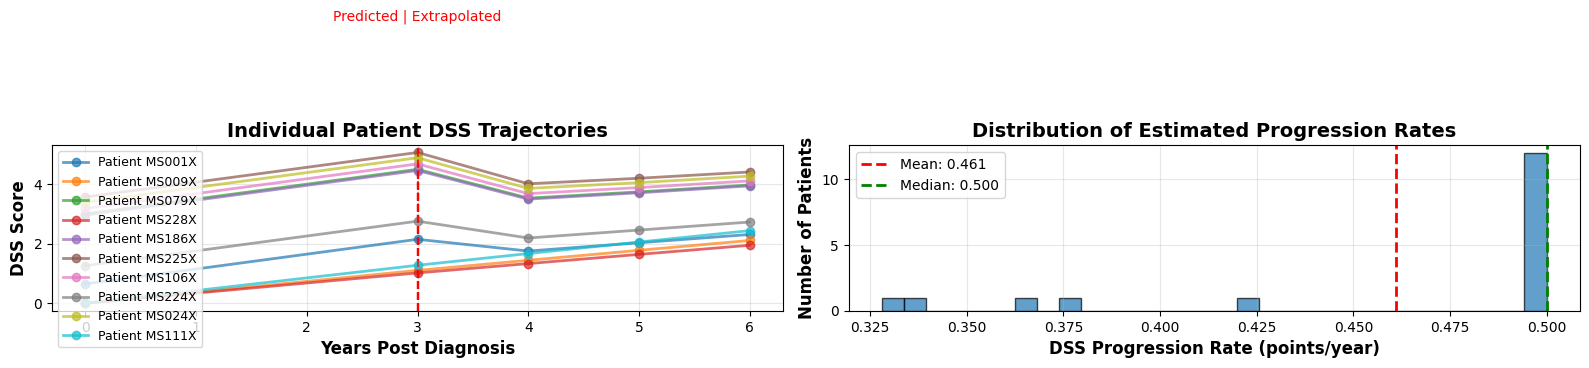


=== Extrapolation Summary Statistics ===
Mean DSS Year 3: 2.94
Mean DSS Year 4: 2.50
Mean DSS Year 5: 2.76
Mean DSS Year 6: 3.03

Mean progression rate: 0.461 DSS points/year
Median progression rate: 0.500 DSS points/year

 0 patients (0.0%) projected to reach DSS ≥ 9.5 by year 6


In [14]:
extrapolated_trajectories = extrapolate_dss_trajectories(predictions)

print("\n=== Extrapolated DSS Trajectories ===")
display(extrapolated_trajectories.head(10))

# Save results
extrapolated_trajectories.to_csv('dss_original_ensemble_trajectories_years3-6.csv', index=False)

# Visualize
plot_patient_trajectories(extrapolated_trajectories, n_patients=10)

# Summary statistics
print("\n=== Extrapolation Summary Statistics ===")
print(f"Mean DSS Year 3: {extrapolated_trajectories['DSS_year3_predicted'].mean():.2f}")
print(f"Mean DSS Year 4: {extrapolated_trajectories['DSS_year4_extrapolated'].mean():.2f}")
print(f"Mean DSS Year 5: {extrapolated_trajectories['DSS_year5_extrapolated'].mean():.2f}")
print(f"Mean DSS Year 6: {extrapolated_trajectories['DSS_year6_extrapolated'].mean():.2f}")
print(f"\nMean progression rate: {extrapolated_trajectories['progression_rate'].mean():.3f} DSS points/year")
print(f"Median progression rate: {extrapolated_trajectories['progression_rate'].median():.3f} DSS points/year")

# Check for patients approaching ceiling
ceiling_patients = extrapolated_trajectories[extrapolated_trajectories['DSS_year6_extrapolated'] >= 9.5]
print(f"\n {len(ceiling_patients)} patients ({len(ceiling_patients)/len(extrapolated_trajectories)*100:.1f}%) projected to reach DSS ≥ 9.5 by year 6")

###Survival-based Model (Weibull_min)

Weibull_min is a flexible survival model often used to capture increasing or decreasing hazard rates.

In [15]:
def extrapolate_with_weibull(original_predictions_df):
    """
    Use Weibull distribution to extrapolate DSS trajectories with proper
    time-varying progression rates based on fitted hazard function.

    Parameters:
    -----------
    original_predictions_df : pd.DataFrame
        Must contain columns: 'patient_id' ('studyid'), 'predicted_dss' (raw predictions)

    Returns:
    --------
    pd.DataFrame with columns: patient_id, DSS_year3-6, progression_rate,
                               weibull_shape, weibull_scale
    """

    # Calculates individual progression rates (baseline to year 3)
    progression_rates = []
    dss_baseline = 2.0  # typical MS onset DSS (clinical literature: 1.0-2.5)

    for idx, row in original_predictions_df.iterrows():
        dss_year3 = row['predicted_dss']
        # Progression rate = (DSS at year 3 - baseline DSS) / 3 years
        rate = (dss_year3 - dss_baseline) / 3.0
        progression_rates.append(rate)

    progression_rates = np.array(progression_rates)

    # Handles negative progression rates
    # DSS rarely decreases in MS (measures permanent disability)
    n_negative = np.sum(progression_rates < 0)
    if n_negative > 0:
        print(f"\nWARNING: {n_negative} patients have negative progression rates")
        print(f"Setting these to 0 (no progression) - DSS rarely improves in MS")
        progression_rates = np.maximum(progression_rates, 0.0)

    # Fits Weibull distribution to the progression rates
    # floc=0 fixes location to 0 (no negative progression rates)
    # f(x) = (k/λ) * (x/λ)^(k-1) * exp(-(x/λ)^k)
    # k = shape parameter - controls the SHAPE of the distribution
    # λ = scale parameter - controls the SPREAD/LOCATION of the distribution
    # x = progression rate
    shape, loc, scale = weibull_min.fit(progression_rates, floc=0)

    print(f"\n{'='*60}")
    print("WEIBULL DISTRIBUTION PARAMETERS")
    print(f"{'='*60}")
    print(f"Shape (k):     {shape:.4f}")
    print(f"Scale (λ):     {scale:.4f}")
    print(f"Location:      {loc:.4f} (fixed)")
    print(f"\nProgression rate statistics:")
    print(f"  Mean:        {progression_rates.mean():.4f} DSS points/year")
    print(f"  Median:      {np.median(progression_rates):.4f} DSS points/year")
    print(f"  Std Dev:     {progression_rates.std():.4f}")
    print(f"  Range:       [{progression_rates.min():.4f}, {progression_rates.max():.4f}]")

    # Interprets the shape parameter
    print(f"\n{'='*60}")
    print("CLINICAL INTERPRETATION")
    print(f"{'='*60}")
    if shape < 1:
        print(f"Shape < 1 -> Decelerating progression")
        print(f"  Disease progression slows over time")
        print(f"  Patients improve or stabilize after initial years")
    elif shape > 1:
        print(f"Shape > 1 -> Accelerating progression")
        print(f"  Disease progression speeds up over time")
        print(f"  Disability worsens at an increasing rate")
    else:
        print(f"Shape ≈ 1 -> Constant progression rate")
        print(f"Linear disease progression over time")
    print(f"{'='*60}\n")

    def apply_clinical_constraints(dss_value, year, base_dss):
        """
        Apply realistic clinical constraints to prevent extreme extrapolations

        Parameters:
        -----------
        dss_value : float
            Predicted DSS value
        year : int
            Year number (4, 5, or 6)
        base_dss : float
            Baseline DSS at year 3

        Returns:
        --------
        float : Constrained DSS value
        """
        # DSS=10 (death) is rare within 6 years for most MS patients
        year_caps = {4: 8.5, 5: 9.0, 6: 9.5}
        max_allowed = year_caps.get(year, 10.0)

        # Limits maximum annual increase to 2.5 DSS points
        # (very aggressive progression, but clinically possible)
        years_elapsed = year - 3
        max_increase = base_dss + (2.5 * years_elapsed)

        # Apply both constraints
        constrained = min(dss_value, max_allowed, max_increase)

        # Floor at 0
        constrained = max(0, constrained)

        return constrained

    results = []

    for idx, row in original_predictions_df.iterrows():
        patient_id = row['patient_id']
        dss_year3 = row['predicted_dss']
        patient_rate = progression_rates[idx]

        # Dampens extremely fast progressors to prevent unrealistic extrapolations
        # Caps at 1.2 DSS points/year (very aggressive but clinically documented)
        if patient_rate > 1.2:
            original_rate = patient_rate
            patient_rate = 1.2
            if idx < 3:  # only print for first few patients
                print(f"Patient {patient_id}: Capped progression rate {original_rate:.3f} -> {patient_rate:.3f}")

        # Calculates Weibull hazard at different time points
        # Time represents years since MS diagnosis
        t_year3 = 3.0
        t_year4 = 4.0
        t_year5 = 5.0
        t_year6 = 6.0

        # Extrapolates using Weibull hazard function
        # Hazard function: h(t) = (k/λ) * (t/λ)^(k-1)
        # Hazard function h(t) = (shape/scale) * (t/scale)^(shape-1)
        # This naturally models how progression changes over time
        def weibull_hazard(t):
            if scale > 0:
                return (shape / scale) * (t / scale) ** (shape - 1)
            return 1.0

        hazard_year3 = weibull_hazard(t_year3)
        hazard_year4 = weibull_hazard(t_year4)
        hazard_year5 = weibull_hazard(t_year5)
        hazard_year6 = weibull_hazard(t_year6)

        # Calculates progression multipliers based on hazard ratios
        # Higher hazard = faster progression
        if hazard_year3 > 0:
            multiplier_4 = hazard_year4 / hazard_year3
            multiplier_5 = hazard_year5 / hazard_year3
            multiplier_6 = hazard_year6 / hazard_year3
        else:
            # Fallbacks to linear if hazard is zero
            multiplier_4 = 1.0
            multiplier_5 = 1.0
            multiplier_6 = 1.0

        # Applies Weibull-adjusted progression
        # Each year's increment is scaled by the hazard ratio
        dss_year4 = dss_year3 + patient_rate * 1.0 * multiplier_4
        dss_year5 = dss_year3 + patient_rate * 2.0 * multiplier_5
        dss_year6 = dss_year3 + patient_rate * 3.0 * multiplier_6

        # Applies clinical constraints before final clipping
        dss_year4 = apply_clinical_constraints(dss_year4, 4, dss_year3)
        dss_year5 = apply_clinical_constraints(dss_year5, 5, dss_year3)
        dss_year6 = apply_clinical_constraints(dss_year6, 6, dss_year3)

        # Final enforcement of DSS valid range [0, 10]
        dss_year4 = np.clip(dss_year4, 0, 10)
        dss_year5 = np.clip(dss_year5, 0, 10)
        dss_year6 = np.clip(dss_year6, 0, 10)

        results.append({
            'patient_id': patient_id,
            'DSS_year3': dss_year3,
            'DSS_year4': dss_year4,
            'DSS_year5': dss_year5,
            'DSS_year6': dss_year6,
            'progression_rate': patient_rate,
            'weibull_shape': shape,
            'weibull_scale': scale
        })

    trajectories_df = pd.DataFrame(results)

    # Summary statistics with clinical warnings
    print(f"\nGenerated trajectories for {len(trajectories_df)} patients")

    # Check for clinical red flags
    n_maxed_year6 = np.sum(trajectories_df['DSS_year6'] >= 9.5)
    if n_maxed_year6 > 0:
        pct_maxed = (n_maxed_year6 / len(trajectories_df)) * 100
        print(f"\n{n_maxed_year6} patients ({pct_maxed:.1f}%) reach DSS ≥ 9.5 by year 6")
        print(f"This is high - consider validating against real longitudinal data if available")

    print(f"\nDSS Summary Statistics:")
    print(trajectories_df[['DSS_year3', 'DSS_year4', 'DSS_year5', 'DSS_year6']].describe())

    print(f"\nProgression Rate Distribution:")
    print(f"  Patients with no progression: {np.sum(trajectories_df['progression_rate'] == 0)}")
    print(f"  Patients with slow progression (<0.3/year): {np.sum(trajectories_df['progression_rate'] < 0.3)}")
    print(f"  Patients with moderate progression (0.3-0.7/year): {np.sum((trajectories_df['progression_rate'] >= 0.3) & (trajectories_df['progression_rate'] < 0.7))}")
    print(f"  Patients with fast progression (≥0.7/year): {np.sum(trajectories_df['progression_rate'] >= 0.7)}")

    return trajectories_df

Visualize trajectories for a number of patients

In [16]:
def plot_weibull_trajectories(trajectories_df, n_patients=5):
    """Plot DSS trajectories for sample patients"""

    fig, axes = plt.subplots(1, 2, figsize=(16, 8))

    # Individual patient trajectories
    ax = axes[0]
    sample_patients = trajectories_df.sample(n=min(n_patients, len(trajectories_df)), random_state=42)

    years = [3, 4, 5, 6]

    for idx, row in sample_patients.iterrows():
        dss_values = [
            row['DSS_year3'],
            row['DSS_year4'],
            row['DSS_year5'],
            row['DSS_year6']
        ]

        # Add slight vertical jitter to DSS values
        jitter = np.random.uniform(-0.08, 0.08, len(dss_values))
        dss_values_jittered = [d + j for d, j in zip(dss_values, jitter)]

        ax.plot(years, dss_values_jittered, marker='o', linewidth=2, alpha=0.7,
                label=f"Patient {row['patient_id']}")

    # Mark the transition from predicted to extrapolated
    ax.axvline(x=3, color='red', linestyle='--', alpha=0.5, linewidth=1.5)

    # Get y-axis range to position text below plot area
    y_min, y_max = ax.get_ylim()
    y_range = y_max - y_min

    # Place text below the plot area, aligned with x=3 (the red line)
    ax.text(3, y_min - 0.15 * y_range, 'Predicted | Extrapolated',
            fontsize=10, ha='center', color='red', va='top',
            bbox=dict(boxstyle='round', facecolor='white', alpha=0.8, edgecolor='red'))

    ax.set_xlabel('Years Post Diagnosis', fontsize=12, fontweight='bold')
    ax.set_ylabel('DSS Score', fontsize=12, fontweight='bold')
    ax.set_title('Individual Patient DSS Trajectories', fontsize=14, fontweight='bold')

    # Move legend outside to the right
    ax.legend(fontsize=9, loc='center left', bbox_to_anchor=(1, 0.5))

    ax.grid(alpha=0.3)

    # Distribution of progression rates
    ax = axes[1]
    progression_rates = trajectories_df['progression_rate']
    ax.hist(progression_rates, bins=30, edgecolor='black', alpha=0.7)
    ax.axvline(progression_rates.mean(), color='red', linestyle='--',
               linewidth=2, label=f'Mean: {progression_rates.mean():.3f}')
    ax.axvline(progression_rates.median(), color='green', linestyle='--',
               linewidth=2, label=f'Median: {progression_rates.median():.3f}')

    ax.set_xlabel('DSS Progression Rate (points/year)', fontsize=12, fontweight='bold')
    ax.set_ylabel('Number of Patients', fontsize=12, fontweight='bold')
    ax.set_title('Distribution of Estimated Progression Rates', fontsize=14, fontweight='bold')
    ax.legend(fontsize=10)
    ax.grid(alpha=0.3)

    plt.tight_layout()
    plt.show()


Setting these to 0 (no progression) - DSS rarely improves in MS

WEIBULL DISTRIBUTION PARAMETERS
Shape (k):     1.1214
Scale (λ):     0.4425
Location:      0.0000 (fixed)

Progression rate statistics:
  Mean:        0.4025 DSS points/year
  Median:      0.2530 DSS points/year
  Std Dev:     0.3968
  Range:       [0.0000, 1.0235]

CLINICAL INTERPRETATION
Shape > 1 -> Accelerating progression
  Disease progression speeds up over time
  Disability worsens at an increasing rate


Generated trajectories for 17 patients

DSS Summary Statistics:
       DSS_year3  DSS_year4  DSS_year5  DSS_year6
count  17.000000  17.000000  17.000000  17.000000
mean    2.943332   3.360127   3.799810   4.256801
std     1.537766   1.953882   2.395686   2.856542
min     0.984243   0.984243   0.984243   0.984243
25%     1.275593   1.275593   1.275593   1.275593
50%     2.759141   3.021182   3.297612   3.584924
75%     4.463071   5.313273   6.210167   7.142364
max     5.070370   6.130201   7.248234   8.410275

Pro

,patient_id,DSS_year3,DSS_year4,DSS_year5,DSS_year6,progression_rate,weibull_shape,weibull_scale
0,MS001X,2.149132,2.200609,2.254914,2.311355,0.049711,1.121394,0.442484
1,MS009X,1.102684,1.102684,1.102684,1.102684,0.000000,1.121394,0.442484
2,MS024X,4.892682,5.891177,6.944508,8.039299,0.964227,1.121394,0.442484
3,MS067X,2.695130,2.935075,3.188197,3.451282,0.231710,1.121394,0.442484
4,MS068X,2.089746,2.120725,2.153405,2.187371,0.029915,1.121394,0.442484
5,MS079X,4.503660,5.367873,6.279546,7.227105,0.834553,1.121394,0.442484
6,MS089X,4.313675,5.112309,5.954801,6.830456,0.771225,1.121394,0.442484
7,MS098X,4.114316,4.844135,5.614034,6.414237,0.704772,1.121394,0.442484
8,MS106X,4.685273,5.612176,6.589981,7.606275,0.895091,1.121394,0.442484
9,MS111X,1.275593,1.275593,1.275593,1.275593,0.000000,1.121394,0.442484


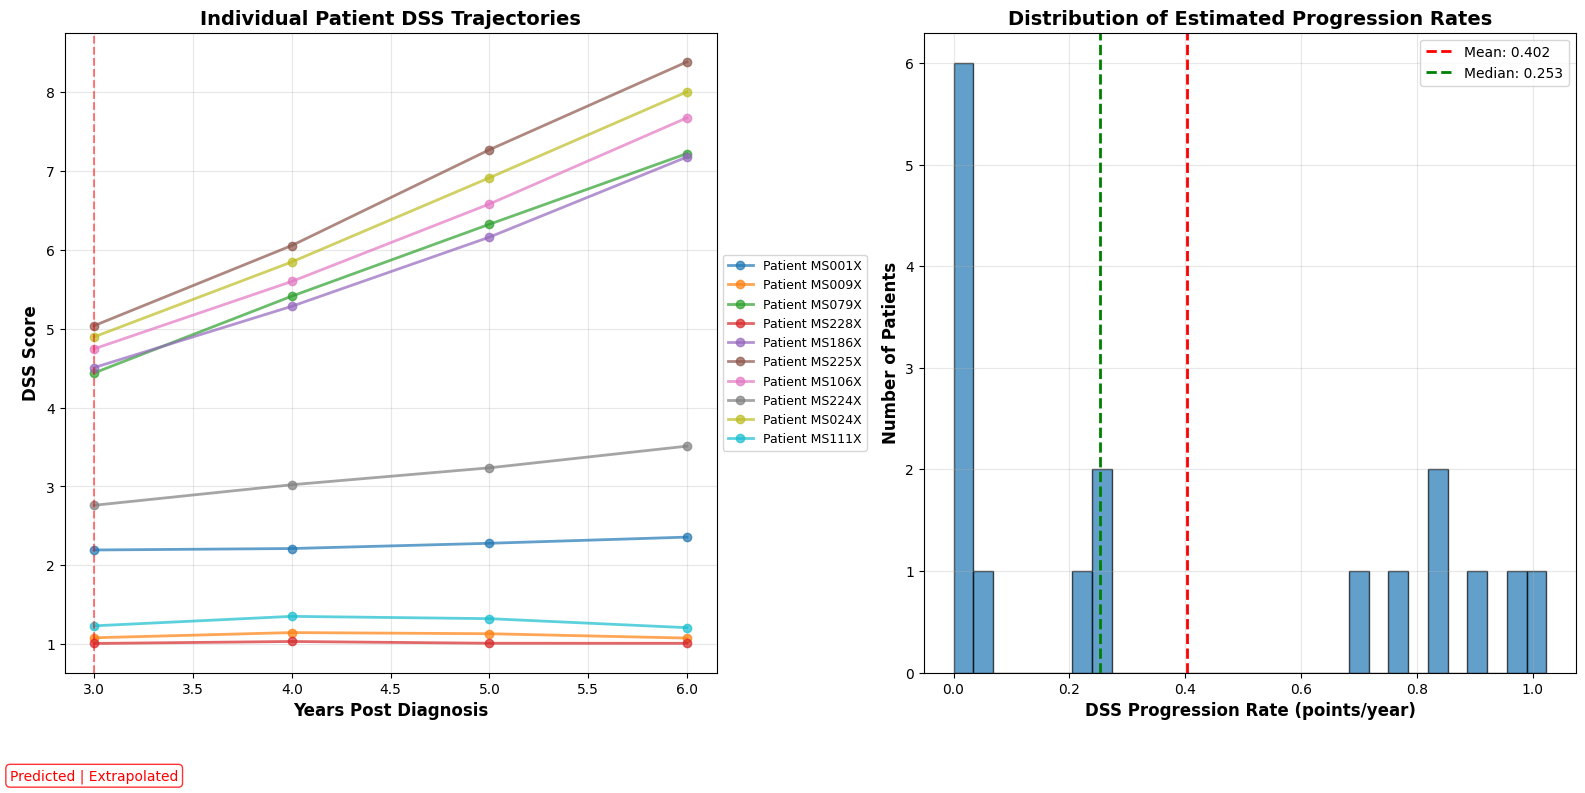


=== Extrapolation Summary Statistics ===
Mean DSS Year 3: 2.94
Mean DSS Year 4: 3.36
Mean DSS Year 5: 3.80
Mean DSS Year 6: 4.26

Mean progression rate: 0.402 DSS points/year
Median progression rate: 0.253 DSS points/year

 0 patients (0.0%) projected to reach DSS ≥ 9.5 by year 6


In [17]:
original_extrapolated_trajectories = extrapolate_with_weibull(predictions)

print("\n=== Extrapolated DSS Trajectories ===")
display(original_extrapolated_trajectories.head(10))

# Save results
original_extrapolated_trajectories.to_csv('dss_original_weibull_min_trajectories_years3-6.csv', index=False)

# Visualize
plot_weibull_trajectories(original_extrapolated_trajectories, n_patients=10)

# Summary statistics
print("\n=== Extrapolation Summary Statistics ===")
print(f"Mean DSS Year 3: {original_extrapolated_trajectories['DSS_year3'].mean():.2f}")
print(f"Mean DSS Year 4: {original_extrapolated_trajectories['DSS_year4'].mean():.2f}")
print(f"Mean DSS Year 5: {original_extrapolated_trajectories['DSS_year5'].mean():.2f}")
print(f"Mean DSS Year 6: {original_extrapolated_trajectories['DSS_year6'].mean():.2f}")
print(f"\nMean progression rate: {original_extrapolated_trajectories['progression_rate'].mean():.3f} DSS points/year")
print(f"Median progression rate: {original_extrapolated_trajectories['progression_rate'].median():.3f} DSS points/year")

# Check for patients approaching ceiling
ceiling_patients = original_extrapolated_trajectories[original_extrapolated_trajectories['DSS_year6'] >= 9.5]
print(f"\n {len(ceiling_patients)} patients ({len(ceiling_patients)/len(original_extrapolated_trajectories)*100:.1f}%) projected to reach DSS ≥ 9.5 by year 6")

In [18]:
def summarize_progression_groups(trajectories_df):
    """Print summary of all progression groups"""

    categories = {
        'No Progression (0)': trajectories_df['progression_rate'] == 0,
        'Slow (<0.3/year)': (trajectories_df['progression_rate'] > 0) &
                            (trajectories_df['progression_rate'] < 0.3),
        'Moderate (0.3-0.7/year)': (trajectories_df['progression_rate'] >= 0.3) &
                                    (trajectories_df['progression_rate'] < 0.7),
        'Fast (≥0.7/year)': trajectories_df['progression_rate'] >= 0.7
    }

    for category_name, mask in categories.items():
        subset = trajectories_df[mask]
        print(f"\n{'='*70}")
        print(f"{category_name}: {len(subset)} patients")
        print(f"{'='*70}")
        if len(subset) > 0:
            print(subset[['patient_id', 'DSS_year3', 'DSS_year6',
                          'progression_rate']].to_string(index=False))
            print(f"\nMean DSS change: {(subset['DSS_year6'] - subset['DSS_year3']).mean():.2f}")
            print(f"Mean progression rate: {subset['progression_rate'].mean():.3f}")


In [19]:
summarize_progression_groups(original_extrapolated_trajectories)


No Progression (0): 5 patients
patient_id  DSS_year3  DSS_year6  progression_rate
    MS009X   1.102684   1.102684               0.0
    MS111X   1.275593   1.275593               0.0
    MS124X   0.984243   0.984243               0.0
    MS216X   1.128936   1.128936               0.0
    MS228X   1.018203   1.018203               0.0

Mean DSS change: 0.00
Mean progression rate: 0.000

Slow (<0.3/year): 5 patients
patient_id  DSS_year3  DSS_year6  progression_rate
    MS001X   2.149132   2.311355          0.049711
    MS067X   2.695130   3.451282          0.231710
    MS068X   2.089746   2.187371          0.029915
    MS224X   2.759141   3.584924          0.253047
    MS241X   2.790794   3.651008          0.263598

Mean DSS change: 0.54
Mean progression rate: 0.166

Moderate (0.3-0.7/year): 0 patients

Fast (≥0.7/year): 7 patients
patient_id  DSS_year3  DSS_year6  progression_rate
    MS024X   4.892682   8.039299          0.964227
    MS079X   4.503660   7.227105          0.834553
  

###Download trajectories

In [20]:
files.download('dss_original_ensemble_trajectories_years3-6.csv')
files.download('dss_original_weibull_min_trajectories_years3-6.csv')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>